
<aside>
📌

***연관 분석 자료를 예습하고 마크다운으로 정리해주세요!***

아래 내용이 필수적으로 들어가야 합니다.

1. **연관 분석**
    - 연관 분석의 정의
    - 지지도, 신뢰도, 향상도
    - 연관 분석의 알고리즘
        - Apriori 알고리즘
        - FP Growth 알고리즘


</aside>

# **연관 분석**

## **1. 연관 분석이란?**

### **1-1. 연관 분석의 정의**
연관 분석이란? (비지도 학습(정답값 별도 존재 X))
- 상품이나 서비스를 구매하는 등 일련의 거래나 사건 안에 존재하는 **항목 간의 일정한 연관 규칙을 발견하는 분석**
- 상품 거래에만 사용되는 것이 아닌, 의사의 질병 진단 등 타 분야에도 폭 넓게 사용 가능
    - 예시
        - **OTT 서비스**: 사용자의 시청 패턴을 분석해 맞춤 콘텐츠를 추천
        - **금융 기관**: 거래 패턴을 통해 사기 행위 탐지 및 맞춤 금융 상품 기획
        - **의료 분야**: 환자의 증상 및 질병 패턴을 분석하여 예방 조치 마련
        - **요식업계**: 인기 메뉴 조합을 찾아 세트 메뉴 개발
- 대표 알고리즘
    - Apriori
    - FP-Growth


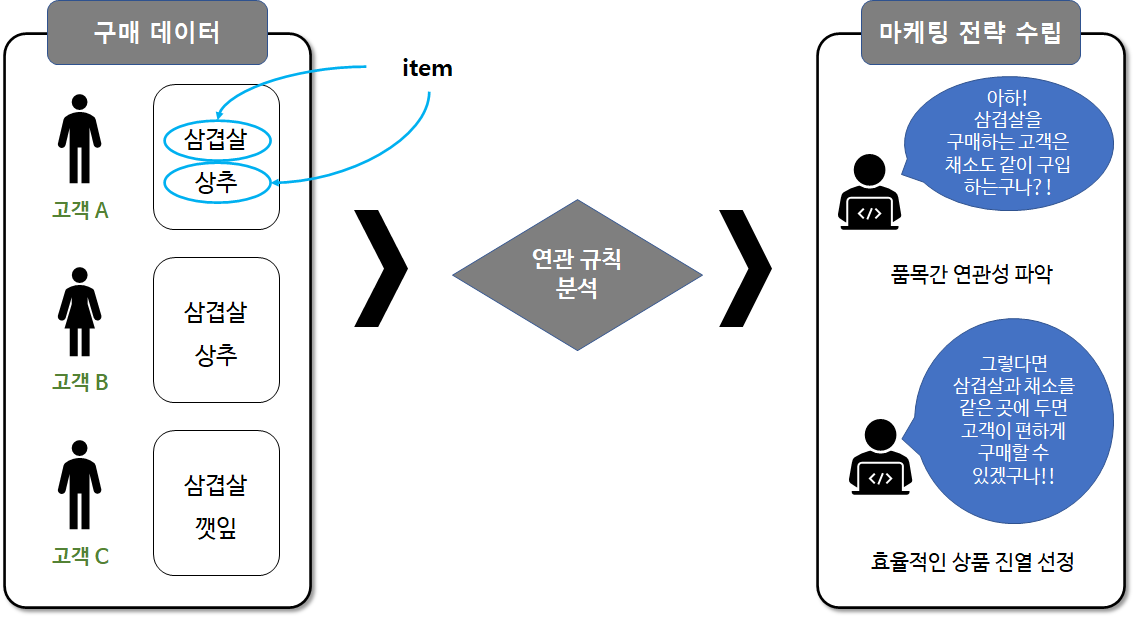

### **1-2. 연관규칙 분석**

#### **연관규칙의 형태**
"A를 구매하였을 떄, B 또한 구매할 것이다."처럼 If-then의 형식을 띄고, A+B로 표현됨.
- **조건절(Antecedent): `**만일 ~라면`에 해당하는 부분
- **결과절(Consequent):** 그 뒷부분에 해당하는 내용
- **아이템 집합(Item set):** 조건절 또는 결과절을 구성하는 아이템들의 집합
    - 여러 개 아이템이 들어가도 되지만 **상호 배반(mutually exclusive)**이어야 함.
        - ex. '맥주를 구매'하는 사람은 '기저귀'를 함께 구매한다.

#### **연관규칙 주의 : 인과관계는 알 수 없다!**
연관규칙은 상관관계를 파악할 뿐, 인과관계는 알 수 없음.

- A + B의 신뢰도 = 0.8 인 경우
    - "A를 산 사람 중 80%는 B도 샀다"
    - 이는 단지 함께 자주 나타난다는 패턴. A를 사서 B를 사게 되었다라는 **원인-결과 관계**는 아님

1. 실험이 아닌 **관찰 데이터**이기 때문
    - "A를 사게 한 원인"이 통제되지 않음
    - ex. A와 B 둘 다 여름 제품일 수도 (숨겨진 공통 원인)
2. 방향성은 그냥 **수학적 비율**일 뿐
    - A -> B는 "A가 원인이다"가 아닌 "A 샀을 때 B 산 비율"이 높은 것 뿐
3. 상관관계 ≠ 인과관계  
    - ex. "얼음 판매량↑ → 아이스크림 판매량↑”
        - 진짜 원인은 "더운 날씨"라는 공변 요인  

## **2. 주요 개념**

### **2-1. (적절한)연관규칙의 조건**

1. 두 품목(품목 A와 B)을 함꼐 구매한 경우의 수가 일정 수준 이상이어야 한다. (**일정 이상의 지지도**)

**지지도**

전체 거래항목 중 품목 A와 품목 B가 동시에 포함하는 거래의 비율

지지도가 낮다면?
- **우연일 수 있는 규칙 포함**
    - 몇 번밖에 등장하지 않은 규칙인데도 우연히 신뢰도가 높을 수 있음 (통계적 신뢰도는 X)
- **실행 가능한 인사이트 도출 어려움**
    - 마케팅/추천/진열 등에 활용하려면 규칙이 충분히 많이 발생해야 의미가 있는데, 지지도가 낮으면 현실에 적용 불가함

-> 즉, **'이 규칙이 현실에서 의미 있는가?'를 판단하는 가장 1차적인 기준**    




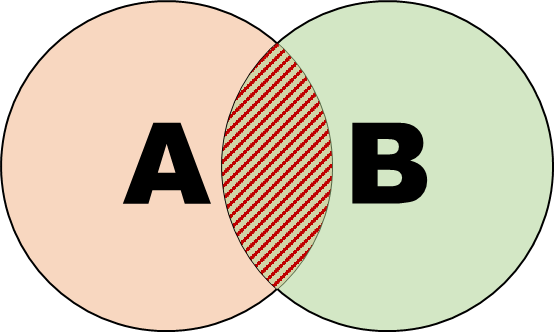

$$
지지도 = P(A \cap B)
$$

**신뢰도**

품목 A를 포함하는 거래 수 중 **품목 A와 품목 B가 동시에 포함되는 거래**의 비율

신뢰도가 낮다면?
- **의미 없는 연관 규칙**
    - A를 샀다고 해도 B는 잘 안 사는 경우
- **추천 실패로 이어짐**
    - 신뢰도가 낮은 규칙을 기반으로 추천하거나 마케팅 타겟팅하면, 클릭률, 전환율 모두 낮아짐
        - 비용은 들고 효과는 없음

-> **A가 일어났을 때, B도 일어날 것이라고 얼마나 확신할 수 있는가?**            

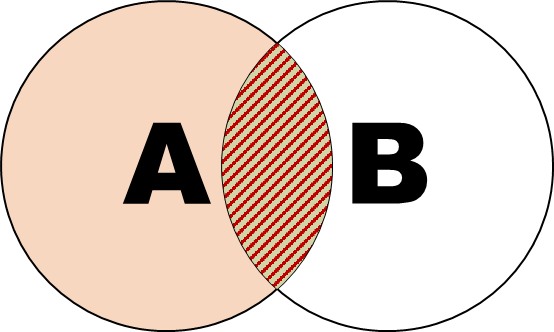

$$
신뢰도 = \frac{P(A \cap B)}{P(A)} = \frac{지지도}{P(A)}
$$

**지지도와 신뢰도 적용 예시**

영화관에서의 '나초 -> 콜라'규칙
- 나초 -> 콜라 지지도 : 10%
    - 매점 전체 결제 중 이 패턴은 10% 존재. 분석할 가치 있음
- 나초 -> 콜라 신뢰도 : 75%
    - 나초 구매한 사람 중 75%는 콜라를 구입. 이 규칙은 꽤나 정확함

**하지만, 신뢰도가 높다고 무조건 좋은 규칙인 것은 아니다.**

예를 들어 이 매점 전체 결제의 85%에 콜라가 포함되어 있을 경우. 나초를 산 사람이 콜라를 살 확률(75%)은 아무나 콜라를 살 확률(85%)보다 낮음.

그렇기 때문에 우리는 A가 B의 판매량에 진짜 유의미한 상관관계가 있는지 확인하는 **향상도**를 측정해야 한다.

### **2-2. 연관 분석의 평가 측도**

#### **3. 향상도**

품목 A가 주어지지 않았을 때의 품목 B의 확률 대비, 품목 A가 주어졌을 때의 품목 B의 확률의 **증가 비율**

핵심 아이디어 : **'A와 B가 우연히 함께 등장할 확률과 실제 함께 등장할 확률을 비교하자."**

$$
향상도 = \frac{P(A \cap B)}{P(A)P(B)} = \frac{신뢰도}{P(B)}
$$

$$
향상도 = \frac{P(A \cap B)}{P(A)P(B)} = \frac{신뢰도}{P(B)}
$$

1. **독립일 때 기댓값**
    - 확률에서 사건 A와 B가 독립이라면
        - $P(A∩B)=P(A)⋅P(B)$
        - 즉, A를 샀다는 사실이 B를 살 확률에 **영향을 주지 않는다**는 뜻
        - 향상도는 1이 됨
            
            $$
            향상도 = \dfrac{P(A∩B)}{P(A)⋅P(B)} = \dfrac{P(A)⋅P(B)}{P(A)⋅P(B)}=1
            $$
            
    - 확률에서 사건 A와 B가 독립이 아니라면
        - $P(A∩B)=P(A)⋅P(B∣A)=P(B)⋅P(A∣B)$
        - 즉, A를 샀다는 사실이 B를 살 확률에 **영향을 주**거나,
        B를 샀다는 사실이 A를 살 확률에 **영향을 준다**는 뜻
        - 실제로 관측한 $P(A∩B)$에 따라 향상도는 1보다 크거나, 1보다 작음

2. **실제 동시 발생 확률**
    - 우리가 실제로 관측한 $P(A∩B)$가,
        
        A와 B가 함께 등장할 확률의 기댓값 $P(A)\cdot P(B)$보다 
        
        - **크면 양의 연관성** (A 사면 B도 잘 삼)
        - **작으면 음의 연관성** (A 산 사람은 B 잘 안 삼)

3. **비율로 비교 -> 향상도**

| 향상도 > 1 | 우연적 기회보다 **높은** 확률 (두 품목이 서로 **양의 상관관계**) |
| --- | --- |
| 향상도 = 1 | 독립 |
| 향상도 < 1 | 우연적 기회보다 **낮은** 확률 (두 품목이 서로 **음의 상관관계**) |

규칙의 효용성은 '지지도, 신뢰도, 향상도' 세 가지를 모두 반영해 평가함

임의의 규칙A가 규칙B보다 효과적인 규칙이려면 **세 지표 모두 클 경우**에만 그렇다고 결론을 내릴 수 있게된다


## **3. 활용 사례**

#### **월마트 Case**

- 딸기맛 팝타르트는 허리케인 직전에 평상시의 약 7배 속도로 팔렸다.
- 허리케인 직전 판매 1위 품목은 맥주였다.
- 팝타르트는 가열이 필요 없고, 냉장 보관이 필요 없으며, 유통기한이 매우 길다 → 정전 상황에 최적화된 식품.

월마트는 이러한 결과를 근거로 허리케인 경로상의 매장에 딸기 팝타르트와 맥주를 실은 트럭을 미리 내려보냈고, 물량은 예상대로 빠르게 소진되었음. 이후 이 패턴은 월마트의 표준 재난 대응 프로세스가 되었음.

**해석**
- **지지도 (Support)**
    - 예시 :
        - "허리케인 경보 기간 중 발생한 전체 거래 중 '생수 등 재난 대비 용품'과 '딸기 팝타르트'가 함께 담긴 장바구니의 비중"
        - 평상시에는 지지도가 낮았지만, 허리케인 상황에서는 이 조합의 지지도가 크게 상승.
    - 해석 :
        - 월마트는 특정 조건 하에서만 유의미해지는 조합을 찾아냄. **전체 기간을 통으로 분석했다면 묻혔을 규칙이라는 점이 핵심.**

- **신뢰도 (Confidence)**
    - 예시 :
        - A: 허리케인 대비 물품(생수, 건전지, 손전등)을 구매
        - B: 딸기 팝타르트를 함께 구매
        - P(B|A)가 충분히 높았다는 것, 즉 재난 대비 장바구니에는 팝타르트가 따라 들어오는 경향이 있다는 의미.
    - 해석: "재난 대비 고객은 조리가 필요 없는 간편식을 함께 산다 -> 이 품목을 함께 진열·비축하면 매출로 직결된다"고 판단.

- **향상도 (Lift)**
    - 예시:
        - A: 허리케인 경보 발령 상황
        - B: 딸기 팝타르트 구매
        - 평상시 구매 확률 대비 약 **7배** → Lift ≈ 7, 즉 1보다 훨씬 큼
    - 해석: A와 B는 독립이 아니며, 두 사건 사이에 강한 양의 상관이 존재. 월마트는 **"왜 하필 딸기맛인가"라는 인과를 설명하지 못했지만, 향상도가 높다는 사실만으로 물류 의사결정을 실행**했습니다. 연관 분석이 인과가 아닌 동시 발생 패턴을 다루는 기법이라는 점을 보여주는 좋은 사례.

## **4. 연관 분석 알고리즘**

### **4-1. Apriori 알고리즘(선형적 경험 이용)**

**배경 : 무차별 탐색의 비효율**
- 연관 규칙을 찾기 위해 가능한 모든 조합을 시도하는 것은 매우 비효율적
    - **가능한 모든 조합** : A(선행조건) -> B(결과조건) 로 표현되도록 하는 모든 경우의 수
    - 이때 A, B는 단일 품목이 아닌 여러 품목으로 구성된 복합 조건이 될 수 있음
- 상품의 개수가 많아질수록 조합의 수가 기하급수적으로 증가

**Apriori 알고리즘 소개**
- 개념 : 상위 조합에서부터 차례로 스캔하며 특정 조합이 자주 발생하지 않는다면 이의 결과물로 탄생한 후속 조합들까지 모두 후보에서 배제하는 방식의 알고리즘
- 장점 : Apriori 알고리즘을 활용하면 하나의 조합만 검사하고도 이에서 파생된 다른 조합들까지 후보에서 배제할 수 있게 되므로 시간과 연산량을 효과적으로 줄일 수 있음.


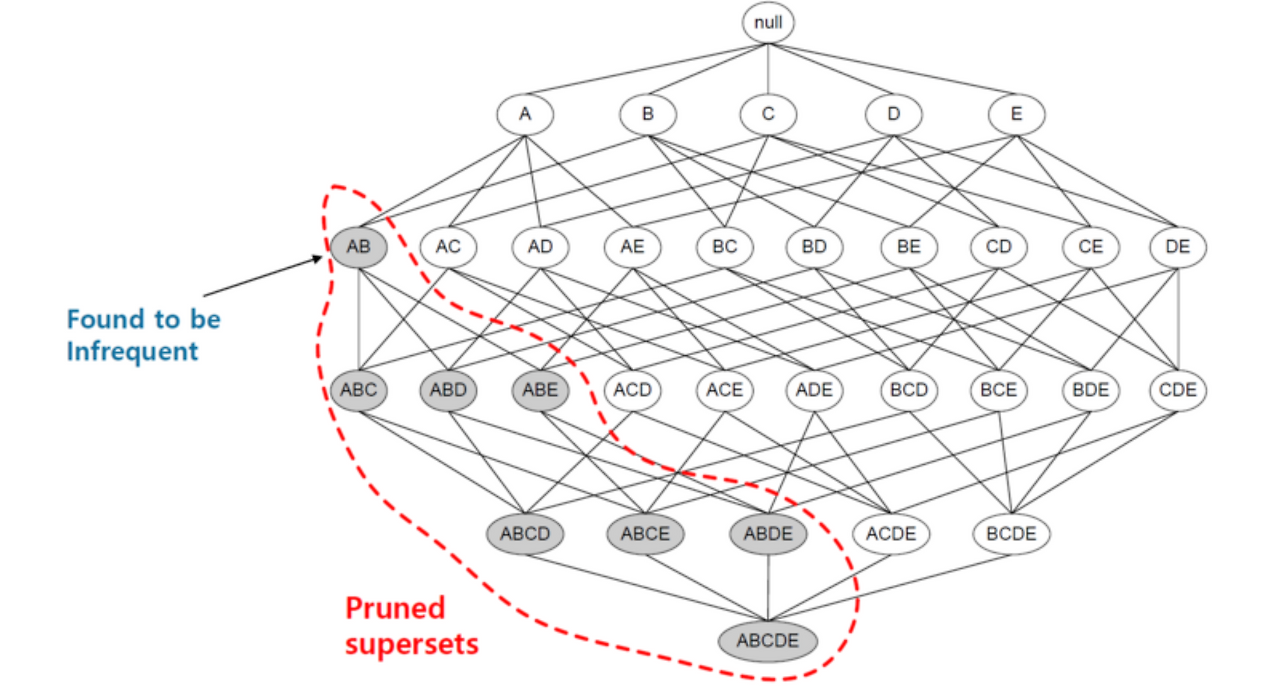

집합 {A,B}의 지지도가 사용자가 정한 최소 지지도를 넘지 못하면, {A,B}를 포함한 {A,B,C},{A,B,D} 등의 모든 규칙들도 모두 한번에 제거가 된다!**

**-> 연산량 감소**


**Apriori 알고리즘 프로세스**

**빈발 항목 집합을 찾고 단계적으로 조합을 생성하고 필터링**
- 빈발 항목 집합 : 일정한 최소 지지도를 넘는 항목들의 조합

1. **단일 항목 집합 생성**
    1. 모든 개별 상품에 대해 지지도 계산
    2. 최소 지지도를 넘는 항목들만 다음 단계로
2. **2개 항목 집합 생성**
    1. 1단계에서 선별된 상품들로 2개 항목의 조합 만듬
    2. 이 조합에 대해 지지도를 계산하고, 최소 지지도를 넘지 않는 조합 제거
3. **더 큰 항목 집합 생성**
    1. 이전 단계에서 남은 조합들을 바탕으로 3개 이상의 항목을 구성된 조합 만듬
    2. 지지도 계산 후 최소 지지도를 넘지 않는 조합 제거
    3. 더 이상 조합을 생성할 수 없을 때 까지 이 과정 반복
4. **최종 빈발 항목 집합 선정**
    1. 마지막으로 남은 빈발 항목 집합들을 바탕으로 연관 규칙 생성
    2. 각 규칙에 대해 지지도, 신뢰도, 향상도를 계산하여 가장 유용한 규칙 선택            


**Apriori 알고리즘 예시**

- **[예시 거래 데이터]**
    - **최소 지지도 : 3/7로 설정**
    
    | ID | Item |
    | --- | --- |
    | 1 | 맥주, 치킨, 햄버거, 라면 |
    | 2 | 맥주, 치킨, 라면 |
    | 3 | 맥주, 치킨 |
    | 4 | 치킨, 햄버거, 라면 |
    | 5 | 치킨, 햄버거 |
    | 6 | 햄버거, 라면 |
    | 7 | 치킨, 라면 | 
    
1. 단일 항목 집합 생성    

| Item | 지지도 |
| --- | --- |
| 맥주 | 3/7 |
| 치킨 | 6/7 |
| 햄버거 | 4/7 |
| 라면 | 5/7 |

2. 2개 항목 집합 생성

| Item | 지지도 |
| --- | --- |
| 맥주, 치킨 | 3/7 |
| ~~맥주, 햄버거~~ | ~~1/7~~ |
| ~~맥주, 라면~~ | ~~2/7~~ |
| 치킨, 햄버거 | 3/7 |
| 치킨, 라면 | 4/7 |
| 햄버거, 라면 | 3/7 |

3. 더 큰 항목 집합 생성

| Item | 지지도 |
| --- | --- |
| ~~맥주, 치킨, 햄버거~~ | ~~1/7~~ |
| ~~맥주, 치킨, 라면~~ | ~~1/7~~ |
| ~~치킨, 햄버거, 라면~~ | ~~2/7~~ |

-> 최소 지지도(3/7)를 넘는 집합 없으므로 알고리즘 종료

4. 최종 빈발 항목 집합 선정

| Item | 지지도 |
| --- | --- |
| 맥주, 치킨 | 3/7 |
| 치킨, 햄버거 | 3/7 |
| 치킨, 라면 | 4/7 |
| 햄버거, 라면 | 3/7 |

- 최소 신뢰도: 0.8로 설정

| Item | 신뢰도 |
| --- | --- |
| 맥주 → 치킨 | 3/3 = 1.0 |
| ~~치킨 → 맥주~~ | ~~3/6 = 0.5~~ |
| ~~치킨 → 햄버거~~ | ~~3/6 = 0.5~~ |
| ~~햄버거 → 치킨~~ | ~~3/4 = 0.75~~ |
| ~~치킨 → 라면~~ | ~~4/6 = 0.667~~ |
| 라면 → 치킨 | 4/5 = 0.8 |
| ~~햄버거 → 라면~~ | ~~3/4 = 0.75~~ |
| ~~라면 → 햄버거~~ | ~~3/5 = 0.6~~ |

- 결과

| Item | 향상도 | 비고 |
| --- | --- | --- |
| 맥주 → 치킨 | $\dfrac{1.0}{6/7}=1.167$ | 양의 상관관계 |
| 라면 → 치킨 | $\dfrac{0.8}{4/7}=0.714$ | 음의 상관관계 |

**Apriori 알괴즘의 장단점**
- **장점**
    - 수많은 상품 연관 구매 패턴 발견
    - 원리가 간단하고, 이해분석이 용이함
- **단점**
    - 여전히 데이터가 커질수록 속도가 느려짐


**Apriori 알고리즘 코드**
```python
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# 최소 지지도를 설정하여 자주 함께 구매되는 상품 조합을 찾기
frequent_itemsets = apriori(df, min_support=0.06, use_colnames=True)

# 연관 규칙을 추출하고, 신뢰도 0.8 이상의 규칙만 추출
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.8)

# 향상도를 기준으로 내림차순 정렬하여 상위 규칙을 확인
top_rules = rules.sort_values(by='lift', ascending=False).head()
```

### **4-2. FP Growth 알고리즘**

Apriori의 연산 속도 문제를 해결할 수 있게 자료구조를 잘 이용한 알고리즘

**배경: 여전히 느리다**
- Apriori 알고리즘은 여전히 데이터가 커질수록 속도가 느려진다는 단점 존재
    - 각 단계에서 데이터를 다시 스캔해야 하기 때문


**FP-Growth 알고리즘 소개** 
- FP-Growth (Frequent pattern Growth) 알고리즘은 빈발  품목 집합을 효율적으로 찾아낸다.
- FP-Tree 라는 구조를 이용하여 Apriori를 효과적으로 구현
- Tree, Array, Linked_List를 합쳐놓은 구조

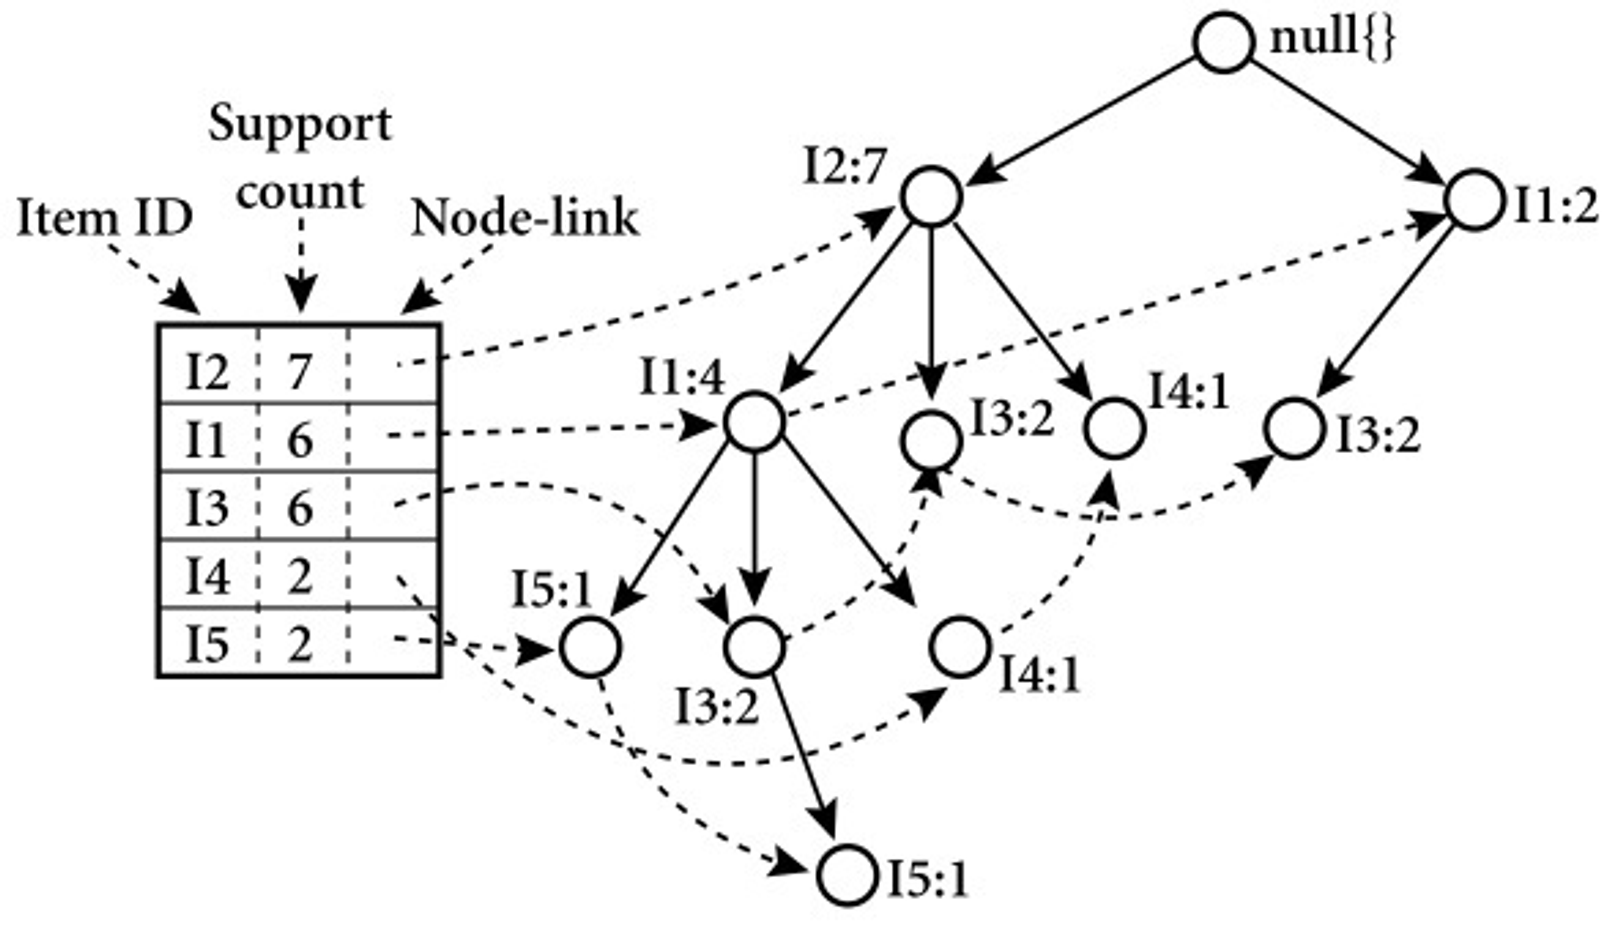

- 모든 거래를 확인해 각 아이템마다 지지도를 계산하고, 최소 지지도 이상의 아이템만 선택
    - 모든 거래에서 빈도가 높은 아이템 순서대로 순서를 정렬
    - 부모 노드를 중심으로 거래를 자식 노드로 추가해주며 tree를 생성
    - 새로운 아이템이 나올 경우 부모노드부터 시작하고, 그렇지 않으면 기존의 노드에서 확장
    - 위의 과정을 모든 거래에 대해 반복하여 FP Tree 를 만들고 최소 지지도 이상의 패턴만 추출

**FP-Growth 알고리즘 프로세스**

모든 항목의 빈도를 계산한 후, 최소 지지도 이상인 항목만을 남김

1. **데이터셋 확인**
2. **빈도순 재정렬**
    - 남은 항목들을 각 거래별로 빈도순으로 재정렬
    - 거래 데이터에서 가장 자주 구매된 항목이 먼저 오도록 재정렬 (f-list)
3. **FP-트리 생성**
    - 재정렬된 데이터 바탕으로 FP-트리 생성.
        - 이 트리는 각 거래를 노드로 표현
        - 동일 항목은 기존 노드에 연결해 빈도를 증가시키고, 새로운 항목은 새로운 노드로 추가
4. **빈발 항목 집합 추출**
    - FP-트리를 바탕으로 특정 항목을 기준으로 부분 트리를 만들어 빈발 항목 집합을 추출
    - 이 부분 트리에서는 기준이 된항목과 연관된 빈발 항목 집합 빠르게 도출 가능
5. **연관 규칙 도출**
    - FP-트리에서 도출된 빈발 항목 집합을 바탕으로 연관 규칙 생성
    - 각 규칙에 대해 지지도, 신뢰도, 향상도 등의 지표를 계산해 가장 유용한 규칙 선택
        - ex. 자주 함께 구매되는 패턴을 발견하여, 이들 간 연관 규칙을 도출해 묶음 판매 전략 수립

**FP-Growth 알고리즘 코드**
```python
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 최소 지지도를 0.06으로 설정하여 빈발 항목 집합을 찾기
frequent_itemsets = fpgrowth(df, min_support=0.06, use_colnames=True)

# 연관 규칙을 추출하고, 신뢰도 0.8 이상의 규칙만 추출
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.8)
```       


